In [2]:
from torchvision import datasets
from torchvision import transforms

import torch
import torch.nn as nn
import sklearn

from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

In [2]:
print('torch version:', torch.__version__)
print('CUDA version:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
print('cuDNN version:', torch.backends.cudnn.version())
print('cuDNN enabled:', torch.backends.cudnn.enabled)
print('GPU name:', torch.cuda.get_device_name(0))

torch version: 2.10.0+cu130
CUDA version: 13.0
CUDA available: True
cuDNN version: 91200
cuDNN enabled: True
GPU name: NVIDIA GeForce RTX 5060


In [3]:
# 激活函数
# 激活函数是神经网络中的非线性函数，用于引入非线性特征，使得神经网络能够学习复杂的模式和关系。
# 常见的激活函数包括ReLU、Sigmoid、Tanh等。
# ReLU函数：f(x) = max(0, x)，当输入大于0时输出输入值，否则输出0。
# Sigmoid函数：f(x) = 1 / (1 + exp(-x))，将输入值压缩到0和1之间。
# Tanh函数：f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))，将输入值压缩到-1和1之间。

# SoftMax 函数
# 函数将一个向量转换为一个概率分布，使得输出的每个元素都在0和1之间，并且所有元素的和为1。
# 公式：softmax(x_i) = exp(x_i) / sum(exp(x_j))，其中x_i是输入向量的第i个元素，x_j是输入向量的所有元素。

# 交叉熵损失函数
# 交叉熵损失函数用于衡量两个概率分布之间的差异，常用于分类问题中。
# 公式：cross_entropy(p, q) = -sum(p_i * log(q_i))，其中p是实际分布，q是预测分布，p_i和q_i分别是第i个元素。

In [18]:
# sample case

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为PyTorch张量，并将像素值归一化到[0, 1]范围内
])

# FashionMNIST数据集是一个包含10个类别的图像数据集，每个类别包含6000张训练图像和1000张测试图像。
# 每张图像是28x28像素的灰度图。
# 加载训练数据集
train_ds = datasets.FashionMNIST(
    root='data',
    train=True, 
    download=True,
    transform=transform
)

# 加载测试数据集
test_ds = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

图像形状: torch.Size([1, 28, 28])
标签: 9
img: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863

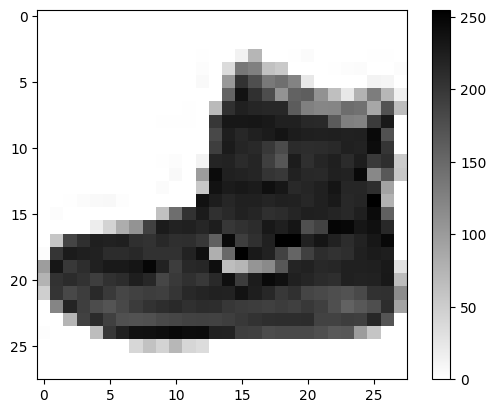

In [31]:
img, label = train_ds[0]
print('图像形状:', img.shape)
print('标签:', label)
print('img:', img)
plt.imshow(transforms.ToPILImage()(img), cmap='binary')
plt.colorbar()
plt.show()